In [ ]:
import sys
sys.path.insert(0, "../src")

from full_pipeline import DRISHTIPipeline
from pathlib import Path

# CONFIG
DATA_DIR = "../data"
OUTPUT_DIR = "../outputs"
DOMAINS = ["artificial_jewellery", "home_cleaning", "shop"]

# Pipeline parameters (can tune)
SAMPLE_RATE = 30
BLUR_THRESHOLD = 100
CONTACT_DIST_PX = 25
MIN_SEGMENT_FRAMES = 5
GAP_MERGE_FRAMES = 3
YOLO_MODEL = "yolov8n.pt"
ENABLE_SMALL_OBJECTS = True

In [ ]:
pipeline = DRISHTIPipeline(
    data_dir=DATA_DIR,
    output_root=OUTPUT_DIR,
    domains=DOMAINS
)

In [ ]:
results, timings = pipeline.run(
    sample_rate=SAMPLE_RATE,
    blur_threshold=BLUR_THRESHOLD,
    dist_thresh_px=CONTACT_DIST_PX,
    min_len_frames=MIN_SEGMENT_FRAMES,
    gap_merge_frames=GAP_MERGE_FRAMES,
    yolo_model=YOLO_MODEL,
    enable_small_objects=ENABLE_SMALL_OBJECTS
)

🔱 DRISHTI — FULL PIPELINE EXECUTION
📂 Data directory: ../data
📂 Output directory: ../outputs
🎯 Domains: artificial_jewellery, home_cleaning, shop

[1/8] 🔍 Scanning videos...
   ✅ Found 3 videos | Time: 0.00s

[2/8] 🎬 Frame extraction & preprocessing...


Batch preprocessing: 100%|██████████| 3/3 [01:14<00:00, 24.77s/it]
I0000 00:00:1777081519.572532  460802 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M3 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1777081519.581673  461770 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777081519.584222  461770 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


   ✅ Processed 3/3 videos | Time: 74.34s

[3/8] 🤲 Hand landmark detection...


Hand detection (videos):   0%|          | 0/10 [00:00<?, ?it/s]/Users/suryanshsingh/Documents/DRISHTI/drishti_env/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Hand detection (videos):  70%|███████   | 7/10 [00:35<00:09,  3.19s/it]/Users/suryanshsingh/Documents/DRISHTI/drishti_env/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Hand detection (videos): 100%|██████████| 10/10 [00:36<00:00,  3.65s/it]


   ✅ Detected hands in 10 videos | Time: 36.59s

[4/8] 📦 Object detection...


...

   ✅ Kinematic features extracted | Time: 0.64s

[7/8] 🎯 Intent inference (Layer 2: WHY)...


Intent inference (videos): 100%|██████████| 7/7 [00:00<00:00, 123.98it/s]


   ✅ Intent labels generated | Time: 0.06s

[8/8] 🤖 Robot skill mapping & skill graph generation (Layer 3: WHAT)...


Robot skill mapping + graph building: 100%|██████████| 7/7 [00:00<00:00, 590.13it/s]

✅ Exported skill graph: ../outputs/skill_graphs/artificial_jewellery/video_20260404_114752_graph.json
✅ Exported skill graph: ../outputs/skill_graphs/artificial_jewellery/video_20260404_115542_graph.json
✅ Exported skill graph: ../outputs/skill_graphs/artificial_jewellery/video_20260404_120254_graph.json
✅ Exported skill graph: ../outputs/skill_graphs/artificial_jewellery/video_20260404_121005_graph.json
✅ Exported skill graph: ../outputs/skill_graphs/artificial_jewellery/video_20260404_121903_graph.json
✅ Exported skill graph: ../outputs/skill_graphs/artificial_jewellery/video_20260405_105612_edit_graph.json
✅ Exported skill graph: ../outputs/skill_graphs/shop/video_20260405_163219_edit_graph.json

🔗 Building master skill graph with cross-domain links...
✅ Added 0 cross-domain skill transfer edges
✅ Exported skill graph: ../outputs/skill_graphs/DRISHTI_master_graph.json

✅ Master graph nodes: 38
✅ Master graph edges: 31
   ✅ Hierarchical skill graph built | Time: 0.02s

✅ DRISHTI PIPE

In [ ]:
pipeline.generate_summary_report()

📄 Summary report saved: ../outputs/DRISHTI_PIPELINE_REPORT.md


In [ ]:
import pandas as pd

master_graph = results['master_graph']

# Load all enriched CSVs
enriched_files = list(Path(OUTPUT_DIR).rglob("*_enriched.csv"))
all_dfs = [pd.read_csv(f) for f in enriched_files if f.stat().st_size > 0]
combined = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

print("=" * 60)
print("📊 FINAL PIPELINE STATISTICS")
print("=" * 60)
print(f"Videos: {len(results['video_records'])}")
print(f"Total segments: {len(combined)}")
print(f"Unique robot skills: {combined['robot_skill'].nunique()}")
print(f"Unique intents: {combined['intent'].nunique()}")
print(f"Graph nodes: {master_graph.number_of_nodes()}")
print(f"Graph edges: {master_graph.number_of_edges()}")
print("\nTop 5 Robot Skills:")
print(combined['robot_skill'].value_counts().head())

📊 FINAL PIPELINE STATISTICS
Videos: 3
Total segments: 31
Unique robot skills: 4
Unique intents: 3
Graph nodes: 38
Graph edges: 31

Top 5 Robot Skills:
robot_skill
dexterous_fine_manipulation    19
precision_sorting               7
precision_placement             4
handover_interaction            1
Name: count, dtype: int64


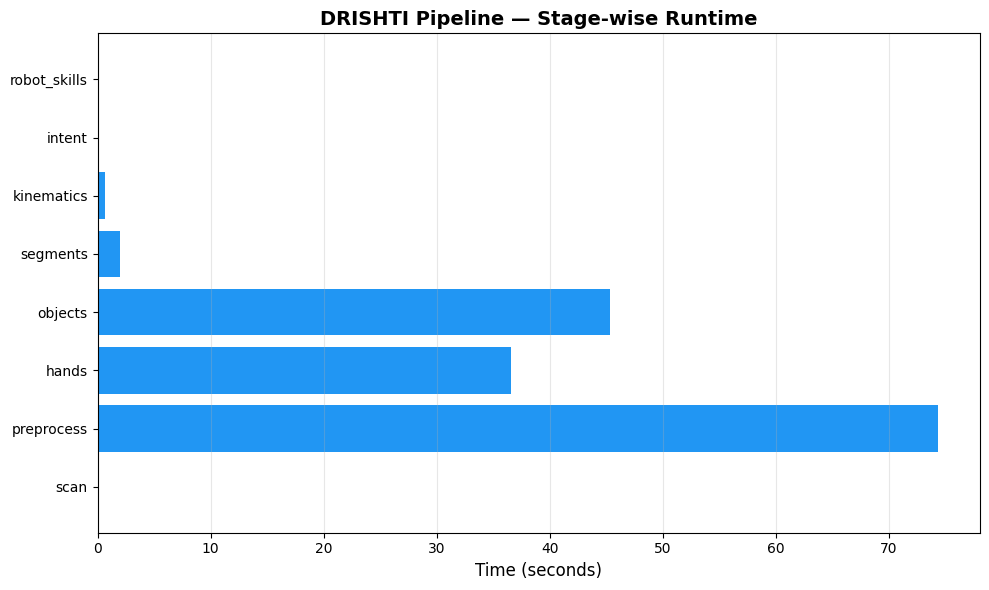

✅ Timing chart saved: ../outputs/pipeline_timing.png


In [ ]:
import matplotlib.pyplot as plt

stages = list(timings.keys())
times = list(timings.values())

plt.figure(figsize=(10, 6))
plt.barh(stages, times, color='#2196F3')
plt.xlabel('Time (seconds)', fontsize=12)
plt.title('DRISHTI Pipeline — Stage-wise Runtime', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pipeline_timing.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Timing chart saved: {OUTPUT_DIR}/pipeline_timing.png")

In [ ]:
import shutil
import json

deliverable_dir = Path(OUTPUT_DIR) / "DRISHTI_DELIVERABLES"
deliverable_dir.mkdir(exist_ok=True)

# Copy key outputs
shutil.copy(
    Path(OUTPUT_DIR) / "skill_graphs" / "DRISHTI_master_graph.json",
    deliverable_dir / "master_skill_graph.json"
)

if (Path(OUTPUT_DIR) / "visualizations" / "skill_graph_interactive.html").exists():
    shutil.copy(
        Path(OUTPUT_DIR) / "visualizations" / "skill_graph_interactive.html",
        deliverable_dir / "interactive_graph.html"
    )

if (Path(OUTPUT_DIR) / "DRISHTI_PIPELINE_REPORT.md").exists():
    shutil.copy(
        Path(OUTPUT_DIR) / "DRISHTI_PIPELINE_REPORT.md",
        deliverable_dir / "report.md"
    )

# Create README
with open(deliverable_dir / "README.md", 'w') as f:
    f.write("# 🔱 DRISHTI — Hierarchical Skill Graph Output\n\n")
    f.write("## 📦 Deliverables\n\n")
    f.write("1. **master_skill_graph.json** — Complete skill graph (JSON-LD format)\n")
    f.write("2. **interactive_graph.html** — Interactive visualization (open in browser)\n")
    f.write("3. **report.md** — Pipeline execution report\n\n")
    f.write("## 🚀 Usage\n\n")
    f.write("Open `interactive_graph.html` in a web browser to explore the graph.\n\n")
    f.write("The JSON-LD graph is compatible with:\n")
    f.write("- NetworkX (Python)\n")
    f.write("- Neo4j (graph database)\n")
    f.write("- Robot learning frameworks (RT-2, Octo, OpenVLA)\n")

print(f"\n✅ Deliverable package created: {deliverable_dir}")
print(f"   Ready to submit or demo!")


✅ Deliverable package created: ../outputs/DRISHTI_DELIVERABLES
   Ready to submit or demo!
